# Build a geospatial query grouping/taxonomy from embeddings

In [1]:
import pandas as pd
import numpy as np
import umap
import csv
from pathlib import Path
import hdbscan
import json

In [3]:
# Load raw queries
queries = pd.read_csv("interim/queries.csv.zip")

# Load query embeddings
xb = np.load("interim/query_emb.npy").astype('float32')  # (n_queries, 384)

# Load classifier results
classifier_results = pd.read_csv('output/queries-classified.20260501.csv.zip')

In [4]:
queries.shape

(1010916, 2)

In [6]:
spatial_idx = classifier_results.is_geospatial_pred.eq(1)

In [7]:
queries[queries.query_text == "earthquake last week in india"]

,query_id,query_text
176910,177371,earthquake last week in india


In [11]:
(queries
    .loc[spatial_idx]
    .loc[queries.query_text.str.contains('which county is') ]
    .sample(10)
)

,query_id,query_text
84216,1007928,which county is noblesville indiana
909278,1140080,which county is whitefish mt in
78662,995143,which county is jsc in?
483610,1007997,"which county is wilson, oklahoma"
5760,1094474,in which county is edwards afb
84238,1007973,which county is smethwick in?
891928,1007989,which county is upland in
119651,1104623,which county is in woodland in
119648,1104619,"which county is spielman road, fairfield, nj"
244746,1007897,which county is laurel md in


## UMAP + HDBSCAN

### Run grid search to find best parameters

1. We reduce embedding dimention with Umap before clustering (384 is too many for hsbscan)
2. No right way of doing it, but let's try 5-10-15 dimensions
3. Try a bunch of other params as well (grid search-like)

In [12]:
xb_spatial = xb[spatial_idx]
xb_spatial.shape

(181827, 384)

### Run grid search to find top parameters

In [14]:
%%time

results = []
config_id = -1

for umap_dim in (5, 10, 15):
    for umap_neighbours in (10, 25, 50):

        reducer = umap.UMAP(
            n_components=umap_dim,
            n_neighbors=umap_neighbours,
            min_dist=0.0,
            metric='cosine',
            n_jobs=1, # -1 for all cores for faster processing but then cannot use random seed...
            random_state=42
        )

        xb_spatial_low = reducer.fit_transform(xb_spatial)
        
        for min_cluster_size in (25, 50, 100, 200):
            for min_samples_ratio in (0.2, 0.5, 1.0):

                config_id += 1
                min_samples = max(5, int(min_cluster_size * min_samples_ratio))
                
                print(f'---- config id: {config_id} ----')
                print('UMAP n dims:', umap_dim)
                print('UMAP n neighbours:', umap_neighbours)
                print('HDBSCAN min cluster size:', min_cluster_size)
                print('HDBSCAN min samples:', min_samples)
        
                clusterer = hdbscan.HDBSCAN(
                    min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric='euclidean',
                    cluster_selection_method='eom',
                    gen_min_span_tree=True
                )

                # Fit the model
                labels = clusterer.fit_predict(xb_spatial_low)

                # Calculate quality metrics
                try: # try/except just in case zero valid clusters
                    dbcv = clusterer.relative_validity_
                except (AttributeError, ValueError):
                    dbcv = float('nan')
                    
                noise = (labels == -1).mean() # -1 aka invalid/noise
                
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # exclude noise -1 cluster
                
                vc = pd.Series(labels[labels != -1]).value_counts()
                median_size = vc.median() if len(vc) else 0

                print(f'DBCV Score: {dbcv}')
                print(f'% invalid/noise/-1 clusters: {noise}')
                print(f'# clusters: {n_clusters}')
                print(f'median cluster size: {median_size}')
                print('*****************')

                # Save results
                results.append({
                    'config_id': config_id,
                    'umap_dim': umap_dim,
                    'umap_neighbours': umap_neighbours,
                    'min_cluster_size': min_cluster_size,
                    'min_samples': min_samples,
                    'dbcv': dbcv,
                    'noise': noise,
                    'n_clusters': n_clusters,
                    'median_size': median_size,
                })

                # Let's save results - will overwrite the old file but OK!
                pd.DataFrame(results).to_csv('interim/grid_search_results.csv', index=False)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


---- config id: 0 ----
UMAP n dims: 5
UMAP n neighbours: 10
HDBSCAN min cluster size: 25
HDBSCAN min samples: 5
DBCV Score: 0.2115880273916269
% invalid/noise/-1 clusters: 0.41879368850610743
# clusters: 1291
median cluster size: 47.0
*****************
---- config id: 1 ----
UMAP n dims: 5
UMAP n neighbours: 10
HDBSCAN min cluster size: 25
HDBSCAN min samples: 12
DBCV Score: 0.20710791590981342
% invalid/noise/-1 clusters: 0.4524410566087545
# clusters: 1107
median cluster size: 49.0
*****************
---- config id: 2 ----
UMAP n dims: 5
UMAP n neighbours: 10
HDBSCAN min cluster size: 25
HDBSCAN min samples: 25
DBCV Score: 0.20575417197394663
% invalid/noise/-1 clusters: 0.4796812354600802
# clusters: 857
median cluster size: 55.0
*****************
---- config id: 3 ----
UMAP n dims: 5
UMAP n neighbours: 10
HDBSCAN min cluster size: 50
HDBSCAN min samples: 10
DBCV Score: 0.23074595895604194
% invalid/noise/-1 clusters: 0.44472493084085424
# clusters: 552
median cluster size: 109.0
***

## Check how stable clustering is

- Umap is stochastic
- Let's rerun umap+hdbscan for top configs several times with different seeds to see how `dbcv` and other qa metrics differ
- We then have more confidence in picking the best params

In [17]:
top_configs = (
    pd.read_csv('interim/grid_search_results.csv')
        .query('n_clusters > 10')
        .sort_values('dbcv', ascending=False)
        .head(10)
)

top_configs.round(3)

,config_id,umap_dim,umap_neighbours,min_cluster_size,min_samples,dbcv,noise,n_clusters,median_size
93,93,15,25,200,40,0.358,0.359,102,449.5
79,79,15,10,100,50,0.341,0.359,182,246.0
81,81,15,10,200,40,0.337,0.388,122,476.0
22,22,5,25,200,100,0.334,0.389,91,467.0
21,21,5,25,200,40,0.333,0.362,105,469.0
95,95,15,25,200,200,0.324,0.417,77,553.0
9,9,5,10,200,40,0.319,0.392,122,443.5
45,45,10,10,200,40,0.317,0.374,114,475.0
23,23,5,25,200,200,0.315,0.426,79,485.0
76,76,15,10,50,25,0.312,0.418,415,119.0


In [19]:
top_configs.dtypes

config_id             int64
umap_dim              int64
umap_neighbours       int64
min_cluster_size      int64
min_samples           int64
dbcv                float64
noise               float64
n_clusters            int64
median_size         float64
dtype: object

In [20]:
%%time

top_config_results = []

for i, config in top_configs.iterrows():

    for seed in [42, 0, 1, 2, 3, 4]: # check 42 again to make sure we can reproduce

        reducer = umap.UMAP(
            n_components=int(config['umap_dim']),
            n_neighbors=int(config['umap_neighbours']),
            min_dist=0.0,
            metric='cosine',
            n_jobs=1,
            random_state=seed
        )

        xb_spatial_low = reducer.fit_transform(xb_spatial)
                    
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=int(config['min_cluster_size']),
            min_samples=int(config['min_samples']), 
            metric='euclidean',
            cluster_selection_method='eom',
            gen_min_span_tree=True
        )

        # Fit the model
        labels = clusterer.fit_predict(xb_spatial_low)

        # Calculate quality metrics
        dbcv = clusterer.relative_validity_
        noise = (labels == -1).mean() # label=-1 for invalid/noise
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # exclude noise (label=-1) cluster
        
        vc = pd.Series(labels[labels != -1]).value_counts()
        median_size = vc.median() if len(vc) else 0

        # Save results
        top_config_results.append({
            'config_id': config['config_id'],
            'umap_dim': config['umap_dim'],
            'umap_neighbours': config['umap_neighbours'],
            'min_cluster_size': config['min_cluster_size'],
            'min_samples': config['min_samples'],
            'seed': seed,
            'dbcv': dbcv,
            'noise': noise,
            'n_clusters': n_clusters,
            'median_size': median_size,
        })

        # Let's save results - will overwrite the old file but OK!
        pd.DataFrame(top_config_results).to_csv(
            'interim/top_config_results.csv',
            index=False
        )

CPU times: user 1h 54min 43s, sys: 1min 15s, total: 1h 55min 59s
Wall time: 1h 58min 16s


# Get cluster labels from the best performing set of umap+hdbscan params

## Let's summarise run consistency per each top config & which config to use

- Probably highest dbcv mean assuming it also has low noise fraction

In [23]:
top_runs = pd.read_csv('interim/top_config_results.csv')

top_runs_stats = top_runs.groupby('config_id').aggregate({
    'dbcv': ('min', 'mean', 'max', 'std'),
    'noise': ('min', 'mean', 'max', 'std'),
    'n_clusters': ('min', 'mean', 'max', 'std')
}).round(3).sort_values([('dbcv', 'mean')], ascending=False)

top_runs_stats

dbcv                       noise                      n_clusters  \
             min   mean    max    std    min   mean    max    std        min   
config_id                                                                      
93.0       0.245  0.364  0.712  0.176  0.000  0.332  0.432  0.165          3   
45.0       0.097  0.363  0.811  0.242  0.000  0.245  0.400  0.190          4   
23.0       0.279  0.326  0.416  0.049  0.341  0.409  0.464  0.040         64   
21.0       0.257  0.310  0.367  0.040  0.358  0.389  0.415  0.027        100   
81.0       0.178  0.306  0.358  0.069  0.001  0.244  0.388  0.189          4   
95.0       0.227  0.289  0.348  0.044  0.410  0.432  0.470  0.026         72   
79.0       0.247  0.282  0.341  0.033  0.344  0.395  0.442  0.038        173   
76.0       0.238  0.279  0.312  0.031  0.412  0.421  0.443  0.011        406   
9.0        0.092  0.271  0.412  0.109  0.000  0.253  0.406  0.196          4   
22.0       0.231  0.269  0.334  0.040  0.389  0.434  0.461  0.033         87   

                                 
              mean  max     std  
config_id                        
93.0        88.333  109  41.908  
45.0        76.667  115  56.326  
23.0        74.667   82   6.377  
21.0       108.167  114   6.242  
81.0        76.667  122  56.631  
95.0        76.000   82   3.406  
79.0       194.833  208  14.303  
76.0       421.000  459  19.442  
9.0         79.167  122  58.321  
22.0        95.667  101   5.428

In [25]:
top_runs_stats.to_csv('interim/top_config_results.summary.csv')

# Pick our top config

Configs 23 and 21 look most stable

- They are the same apart from `min_samples` (40 for config 21; 200 for config 23)
- Basically a choice between looser, fine-grained clustering (21) and coarser clustering (23)
- Let's go with 21
- Let's go with the average seed (42) instead of cherry-picking the best run

In [30]:
top_runs.query(f'config_id == 21')

,config_id,umap_dim,umap_neighbours,min_cluster_size,min_samples,seed,dbcv,noise,n_clusters,median_size
24,21.0,5.0,25.0,200.0,40.0,42,0.333438,0.362009,105,469.0
25,21.0,5.0,25.0,200.0,40.0,0,0.257053,0.415180,114,507.5
26,21.0,5.0,25.0,200.0,40.0,1,0.325540,0.373872,103,439.0
27,21.0,5.0,25.0,200.0,40.0,2,0.304029,0.415202,113,472.0
28,21.0,5.0,25.0,200.0,40.0,3,0.274798,0.407767,114,456.5
29,21.0,5.0,25.0,200.0,40.0,4,0.366837,0.357972,100,471.5


In [31]:
top_runs.query(f'config_id == 23')

,config_id,umap_dim,umap_neighbours,min_cluster_size,min_samples,seed,dbcv,noise,n_clusters,median_size
48,23.0,5.0,25.0,200.0,200.0,42,0.314783,0.426422,79,485.0
49,23.0,5.0,25.0,200.0,200.0,0,0.416001,0.341143,64,567.5
50,23.0,5.0,25.0,200.0,200.0,1,0.279200,0.400447,76,569.0
51,23.0,5.0,25.0,200.0,200.0,2,0.287887,0.464304,82,590.0
52,23.0,5.0,25.0,200.0,200.0,3,0.319403,0.403009,71,648.0
53,23.0,5.0,25.0,200.0,200.0,4,0.339249,0.418447,76,579.5


In [37]:
config_choice = top_runs.query('config_id == 21 and seed == 42').iloc[0].astype(int)
config_choice

config_id            21
umap_dim              5
umap_neighbours      25
min_cluster_size    200
min_samples          40
seed                 42
dbcv                  0
noise                 0
n_clusters          105
median_size         469
Name: 24, dtype: int64

In [38]:
%%time

reducer = umap.UMAP(
    n_components=config_choice.umap_dim,
    n_neighbors=config_choice.umap_neighbours,
    min_dist=0.0,
    metric='cosine',
    n_jobs=1,
    random_state=config_choice.seed
)
    
xb_spatial_low = reducer.fit_transform(xb_spatial)
            
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=config_choice.min_cluster_size,
    min_samples=config_choice.min_samples, 
    metric='euclidean',
    cluster_selection_method='eom',
    gen_min_span_tree=True
)

# Get the lables
labels = clusterer.fit_predict(xb_spatial_low)

CPU times: user 2min 9s, sys: 1.38 s, total: 2min 10s
Wall time: 2min 13s


In [39]:
print( len(labels) )
assert len(set(labels)) == (config_choice.n_clusters + 1) # adding -1 for noise cluster

181827


## Manually review clusters

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cdist

In [41]:
def analyze_clusters(queries, labels, embeddings, top_n_words=20, sample_size=10):
    df = pd.DataFrame({'query': queries, 'label': labels})
    unique_labels = sorted(df['label'].unique())

    # class-based tf–idf
    docs_per_class = (
        df.groupby('label')['query']
        .apply(lambda x: ' '.join(x))
        .reset_index()
        .sort_values('label')
        .reset_index(drop=True)
    )

    tfidf_model = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    tfidf_matrix = tfidf_model.fit_transform(docs_per_class['query'])
    words = tfidf_model.get_feature_names_out()

    rows = []

    for i, label in enumerate(unique_labels):
        idx = df.index[df['label'] == label]
        cluster_embeddings = embeddings[idx]
        cluster_queries = df.loc[idx, 'query'].values

        # centroid representative
        centroid = cluster_embeddings.mean(axis=0).reshape(1, -1)
        distances = cdist(centroid, cluster_embeddings, 'cosine')[0]
        rep_query = cluster_queries[distances.argmin()]

        # top tf–idf terms
        row_data = tfidf_matrix.getrow(i).toarray()[0]
        top_idx = row_data.argsort()[-top_n_words:][::-1]
        top_terms = [words[j] for j in top_idx]

        # sample queries
        sample_queries = (
            df.loc[idx, 'query']
            .sample(min(len(idx), sample_size), random_state=42)
            .tolist()
        )

        rows.append({
            'label': label,
            'n_samples': len(idx),
            'representative_query': rep_query,
            'top_terms': top_terms,
            'sample_queries': sample_queries,
        })

    return pd.DataFrame(rows).sort_values('label').reset_index(drop=True)


def clusters_df_to_markdown(clusters_df):
    sections = []

    for _, row in clusters_df.iterrows():
        section = [
            f'## Cluster {row["label"]} ({row["n_samples"]} samples)',
            f'**Representative Query:** `{row["representative_query"]}`',
            f'**Top Terms:** {", ".join(row["top_terms"])}',
            '',
            '**Sample Queries:**',
            '\n'.join(f'- {q}' for q in row['sample_queries']),
            '',
            '---',
        ]
        sections.append('\n'.join(section))

    return '\n'.join(sections)

In [48]:
final_clusters = analyze_clusters(
    queries[spatial_idx].reset_index().query_text,
    labels,
    xb[spatial_idx]
)

In [49]:
final_clusters.to_excel('interim/cluster_review.xlsx', index=False)

##### Convert to markdown for easier edits

In [50]:
final_clusters_markdown = clusters_df_to_markdown(final_clusters)

In [51]:
with open('interim/cluster_review.md', 'w') as f:
    f.write(final_clusters_markdown)

## Convert spreadsheet to Vega JSON

In [66]:
data = pd.read_excel('interim/cluster_review.xlsx')

In [90]:
data_size = data.n_samples.sum()
other_size = data[data.label == -1].iloc[0].n_samples

In [71]:
groups = data.group.dropna().unique()
groups.size

14

In [72]:
groups

array(['US places', 'Earth & physical sciences', 'Business & commerce',
       'Government & politics', 'Media & sports', 'Biographical',
       'World geography', 'Education', 'Travel & transport', 'History',
       'Demographics & society', 'Structures', 'Built features',
       'Living world'], dtype=object)

In [79]:
group_colours = {
    'US places' : '#2f4f4f',
    'Earth & physical sciences' : '#7f0000',
    'Business & commerce' : '#191970',
    'Government & politics' : '#008000',
    'Media & sports' : '#ff8c00',
    'Biographical' : '#ffff00',
    'World geography' : '#deb887',
    'Education' : '#00ff00',
    'Travel & transport' : '#00bfff',
    'History' : '#0000ff',
    'Demographics & society' : '#ff00ff',
    'Structures' : '#dda0dd',
    'Built features' : '#ff1493',
    'Living world' : '#7fffd4',
    'Other': '#999999'
}

In [75]:
group_counts = data.groupby(['group']).n_samples.sum().reset_index()
group_counts

,group,n_samples
0,Biographical,2447
1,Built features,811
2,Business & commerce,40190
3,Demographics & society,6204
4,Earth & physical sciences,18897
5,Education,3039
6,Government & politics,3046
7,History,5059
8,Living world,3496
9,Media & sports,3908


<Axes: >

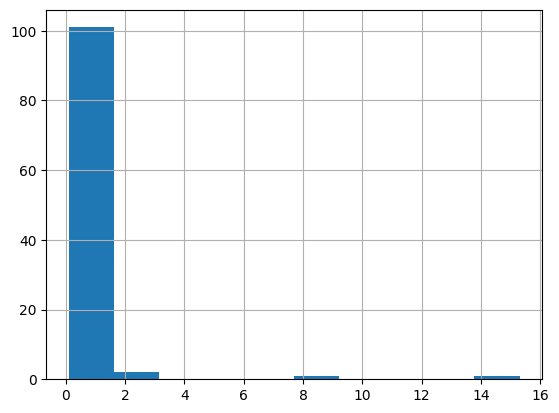

In [94]:
leaf_counts = data.groupby(['group', 'name']).n_samples.sum().reset_index().assign(
    pc=lambda df_: (df_.n_samples / data_size *100).round(1)
)

leaf_counts.pc.hist()

In [98]:
leaf_counts

,group,name,n_samples,pc
0,Biographical,Birthplaces & residences (people),1744,1.0
1,Biographical,Burial sites,249,0.1
2,Biographical,Schools attended (people),217,0.1
3,Biographical,Surname & place name origins,237,0.1
4,Built features,Construction dates of landmarks,811,0.4
...,...,...,...,...
100,World geography,Lakes & natural water features,368,0.2
101,World geography,Latitude & longitude,206,0.1
102,World geography,Mountains & elevation,948,0.5
103,World geography,Rivers,396,0.2


In [95]:
root = [{"id": "root", "name": "Geospatial queries"}]

group_level = [{
    "id": row['group'],
    "name": row['group'],
    "parent": "root",
    "size": int(row['n_samples']),
    'colour': group_colours.get(row['group'], '#000000')
} for _, row in group_counts.sort_values('n_samples', ascending=False).iterrows() ]

leaf_level = [{
    "id": row['name'],
    "name": row['name'],
    "parent": row['group'],
    "size": int(row['n_samples']),
    'colour': group_colours.get(row['group'], '#000000')
} for _, row in leaf_counts.sort_values('n_samples', ascending=False).iterrows()]

other_bubble = [{
    'id': 'Other',
    'name': 'Misc',
    'parent': 'root',
    'size': int(other_size),
    'colour': group_colours.get('Other', '#000000')
}]

In [96]:
nodes = root + group_level + leaf_level + other_bubble

In [97]:
with open('visual/data.json', 'w') as f:
    f.write(json.dumps(nodes))